In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("dataset_performance.csv")
print(df)

       student_id  age  gender             major  study_hours_per_day  \
0          100000   26    Male  Computer Science             7.645367   
1          100001   28    Male              Arts             5.700000   
2          100002   17    Male              Arts             2.400000   
3          100003   27   Other        Psychology             3.400000   
4          100004   25  Female          Business             4.700000   
...           ...  ...     ...               ...                  ...   
79995      179995   16    Male       Engineering             3.700000   
79996      179996   16  Female          Business             1.200000   
79997      179997   26  Female              Arts             4.100000   
79998      179998   23   Other           Biology             3.800000   
79999      179999   25   Other       Engineering             3.000000   

       social_media_hours  netflix_hours part_time_job  attendance_percentage  \
0                     3.0            0.1  

In [3]:
# adding Column "exam_result" saying the student is 'PASS' or 'FAIL'
df['exam_result']=df['exam_score'].apply(lambda x:'PASS' if x>=45 else'FAIL')
print(df)

       student_id  age  gender             major  study_hours_per_day  \
0          100000   26    Male  Computer Science             7.645367   
1          100001   28    Male              Arts             5.700000   
2          100002   17    Male              Arts             2.400000   
3          100003   27   Other        Psychology             3.400000   
4          100004   25  Female          Business             4.700000   
...           ...  ...     ...               ...                  ...   
79995      179995   16    Male       Engineering             3.700000   
79996      179996   16  Female          Business             1.200000   
79997      179997   26  Female              Arts             4.100000   
79998      179998   23   Other           Biology             3.800000   
79999      179999   25   Other       Engineering             3.000000   

       social_media_hours  netflix_hours part_time_job  attendance_percentage  \
0                     3.0            0.1  

Accuracy: 1.00


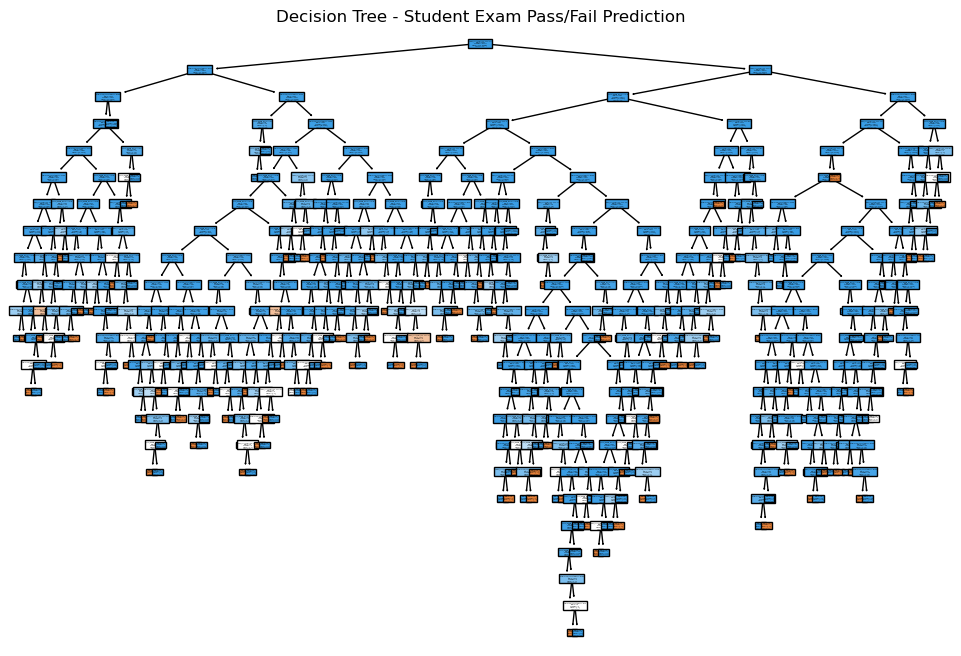

In [7]:
#Decision tree
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("dataset_performance.csv")

# Create pass/fail flag from exam_score (if no exam_result column exists)
df["pass_flag"] = (df["exam_score"] >= 50).astype(int)

# Define features and target
features = ["study_hours_per_day", "social_media_hours", "attendance_percentage"]
X = df[features]
y = df["pass_flag"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Evaluate model
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Plot decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=features, class_names=["FAIL", "PASS"])
plt.title("Decision Tree - Student Exam Pass/Fail Prediction")
plt.show()


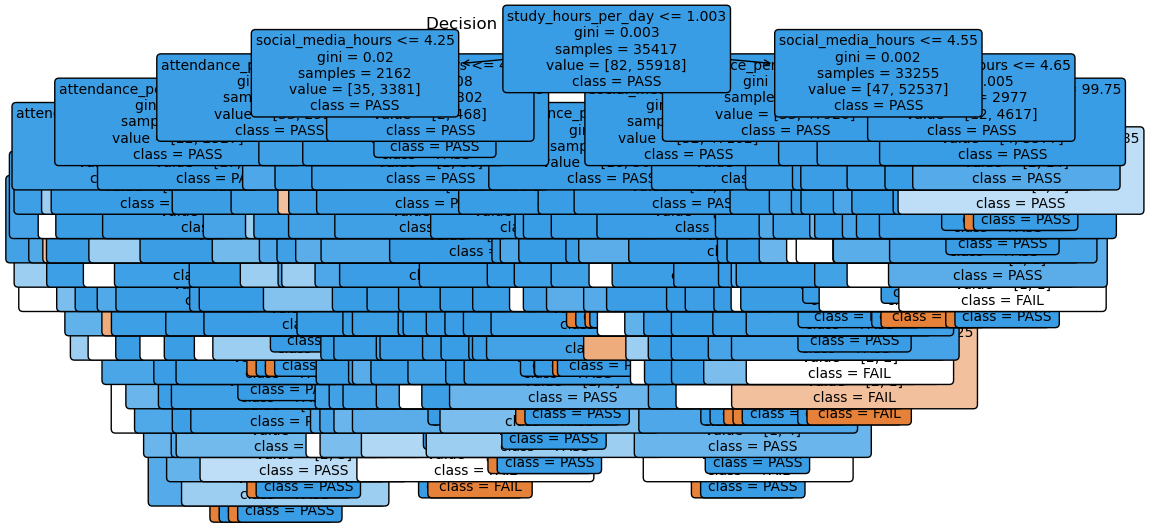

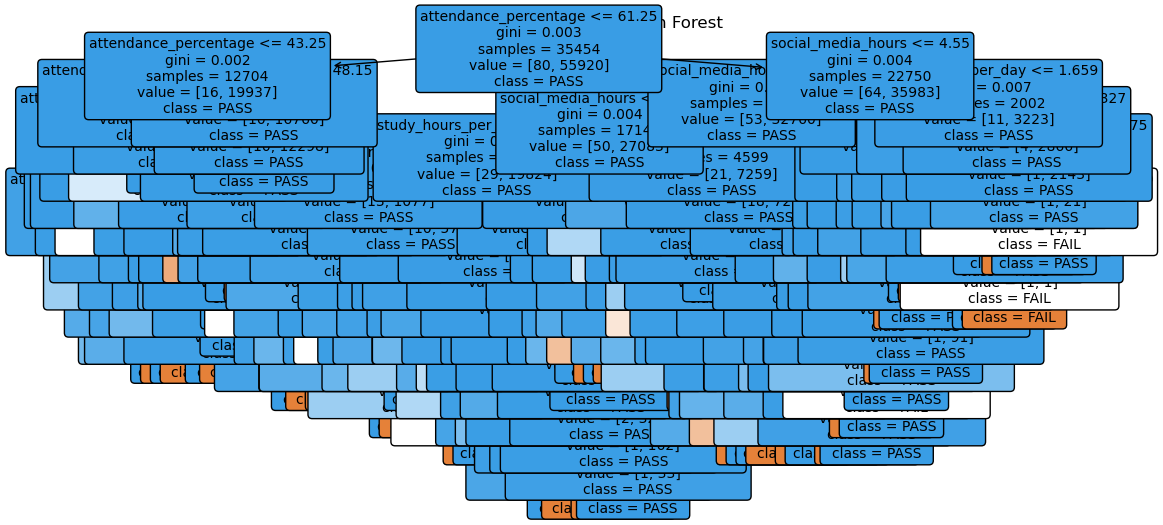

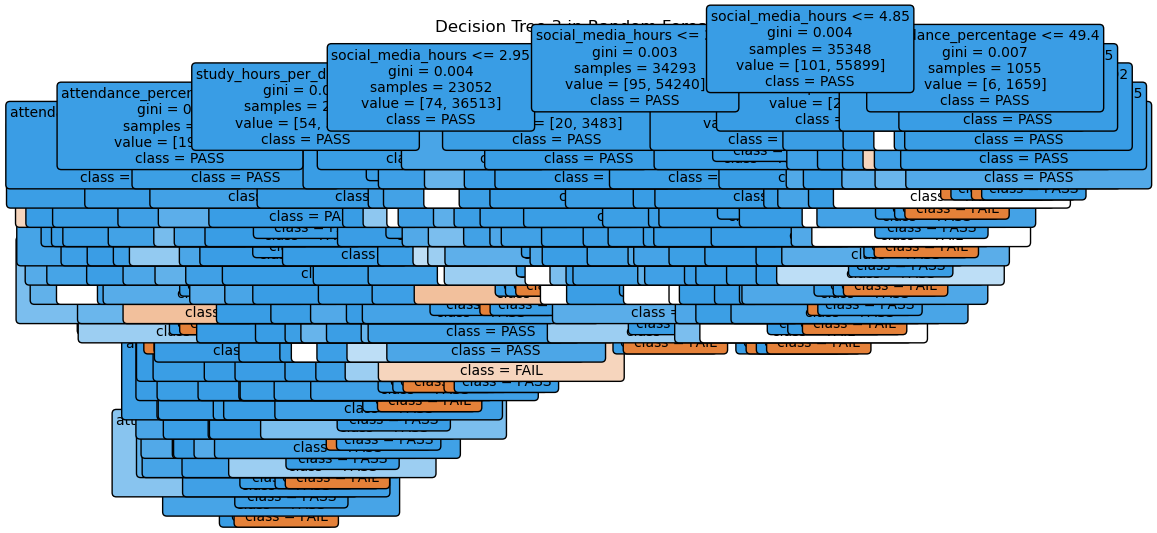

C:\Users\E VAHINI\anaconda3\envs\tensorflow\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\E VAHINI\anaconda3\envs\tensorflow\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\E VAHINI\anaconda3\envs\tensorflow\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(



Tree 1 Predictions:
[1. 1. 1. ... 1. 1. 1.]

Tree 2 Predictions:
[1. 1. 1. ... 1. 1. 1.]

Tree 3 Predictions:
[1. 1. 1. ... 1. 1. 1.]

🎯 Final Predictions (Majority Vote):
[1. 1. 1. ... 1. 1. 1.]

✅ Final Accuracy (Random Forest with 3 Trees): 1.00


In [6]:
#Random Forest
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from scipy.stats import mode
import numpy as np

# Step 1: Load your dataset
df = pd.read_csv("dataset_performance.csv")

# Step 2: Create binary classification target (pass if score ≥ 50)
df['pass_flag'] = (df['exam_score'] >= 50).astype(int)

# Step 3: Select features
features = ["study_hours_per_day", "social_media_hours", "attendance_percentage"]
X = df[features]
y = df['pass_flag']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Step 5: Train Random Forest with 3 decision trees
rf = RandomForestClassifier(n_estimators=3, random_state=42)
rf.fit(X_train, y_train)

# Step 6: Visualize each tree
for i, tree in enumerate(rf.estimators_):
    plt.figure(figsize=(12, 6))
    plot_tree(
        tree,
        feature_names=features,
        class_names=["FAIL", "PASS"],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f"Decision Tree {i+1} in Random Forest")
    plt.show()

# Step 7: Get predictions from each tree
all_preds = []
for i, tree in enumerate(rf.estimators_):
    preds = tree.predict(X_test)
    all_preds.append(preds)
    print(f"\nTree {i+1} Predictions:\n{preds}")

# Step 8: Final prediction by majority vote
all_preds = np.array(all_preds)
final_pred, _ = mode(all_preds, axis=0, keepdims=True)
final_pred = final_pred.flatten()

print("\n🎯 Final Predictions (Majority Vote):")
print(final_pred)

# Step 9: Accuracy
acc = accuracy_score(y_test, final_pred)
print(f"\n✅ Final Accuracy (Random Forest with 3 Trees): {acc:.2f}")
